In [ ]:
!pip install tensorflow

In [1]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense,Flatten
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
tf.__version__

'2.19.0'

In [3]:
#load_data
(X_train,y_train),(X_test,y_test)=keras.datasets.mnist.load_data()

In [4]:
len(X_train)

60000

In [5]:
X_train.shape

(60000, 28, 28)

In [6]:
type(X_train)

numpy.ndarray

In [7]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [8]:
X_train[0].shape

(28, 28)

In [9]:
for row in X_train[0]:
    row=row.tolist()
    for i in row:
        print(str(i).ljust(4), end='')
    print()

0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   
0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   
0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   
0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   
0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   
0   0   0   0   0   0   0   0   0   0   0   0   3   18  18  18  126 136 175 26  166 255 247 127 0   0   0   0   
0   0   0   0   0   0   0   0   30  36  94  154 170 253 253 253 253 253 225 172 253 242 195 64  0   0   0   0   
0   0   0   0   0   0   0   49  238 253 253 253 253 253 253 253 253 251 93  82  82  56  39  0   0   0   0   0   
0   0   0   0   0   0   0   18  219 253 253 253 253 253 198 182 247 241 0   0   0   0   0   0   

(-0.5, 27.5, 27.5, -0.5)

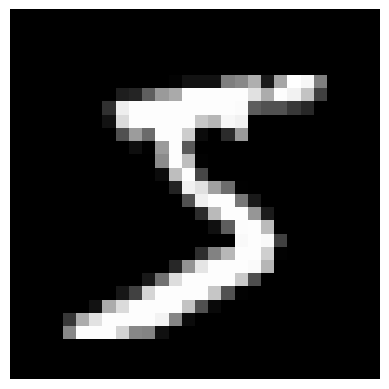

In [10]:
plt.imshow(X_train[0], cmap='gray')
plt.axis('off')

In [11]:
y_train[0]

5

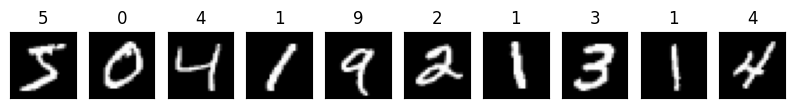

In [11]:
# Display some images
fig, axes = plt.subplots(ncols=10, sharex=False,
                         sharey=True, figsize=(10, 4))
for i in range(10):
    axes[i].set_title(y_train[i])
    axes[i].imshow(X_train[i], cmap='gray')
    axes[i].get_xaxis().set_visible(False)
    axes[i].get_yaxis().set_visible(False)
plt.show()

In [13]:
#Scaling pixel values
X_train=X_train/255
X_test=X_test/255

In [14]:
for row in X_train[0]:
    row=row.tolist()
    for i in row:
        print(str(i).ljust(4), end=' ')
    print()

0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.011764705882352941 0.07058823529411765 0.07058823529411765 0.07058823529411765 0.49411764705882355 0.5333333333333333 0.6862745098039216 0.10196078431372549 0.6509803921568628 1.0  0.9686274509803922 0.4980392156862745 0.0  0.0  0.0 

In [15]:
# Round values to three decimal places
X_train = np.round(X_train, 3)

X_test = np.round(X_test, 3)

In [16]:
for row in X_train[0]:
    row=row.tolist()
    for i in row:
        print(str(i).ljust(4), end=' ')
    print()

0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.012 0.071 0.071 0.071 0.494 0.533 0.686 0.102 0.651 1.0  0.969 0.498 0.0  0.0  0.0  0.0  
0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.118 0.141 0.369 0.604 0.667 0.992 0.992 0.992 0.992 0.992 0.882 0.675 0.992 0.949 0.765 0.251 0.0  0.

In [16]:
#Creating ANN with a simple apprach

In [23]:
model=Sequential()

The Flatten layer is a type of layer in Keras that reshapes multi-dimensional input into a single-dimensional vector (a one-dimensional array)

input_shape=(28, 28) specifies the shape of each input image in the dataset.

When the Flatten layer receives an input of shape (28, 28), it transforms it into a 1D array of 784 elements (since 28×28=784)


In [24]:

input_layer=Flatten(input_shape=(28,28), name='input_layer0')

In [25]:
layer1=Dense(units=100,activation='relu',name='hidden_layer_1')

In [26]:
layer2=Dense(units=50,activation='relu',name='hidden_layer_2')

In [27]:
output_layer=Dense(units=10,activation='softmax',name='output_layer')

In [28]:
model.add(input_layer)
model.add(layer1)
model.add(layer2)
model.add(output_layer)

In [29]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer0 (Flatten)          │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_1 (Dense)          │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,060 (328.36 KB)

 Trainable params: 84,060 (328.36 KB)

 Non-trainable params: 0 (0.00 B)

The parameter loss='sparse_categorical_crossentropy' is used in Keras when training a model for multi-class classification tasks. It’s a type of cross-entropy loss function specifically designed to handle integer-labeled categorical data.

In [30]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [31]:
training_history=model.fit(X_train,y_train,epochs=5,validation_data=(X_test,y_test),verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8687 - loss: 0.4540 - val_accuracy: 0.9583 - val_loss: 0.1307
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9630 - loss: 0.1222 - val_accuracy: 0.9686 - val_loss: 0.0975
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9743 - loss: 0.0824 - val_accuracy: 0.9750 - val_loss: 0.0801
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9814 - loss: 0.0600 - val_accuracy: 0.9733 - val_loss: 0.0792
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9851 - loss: 0.0482 - val_accuracy: 0.9734 - val_loss: 0.0919


In [54]:
training_history.history

{'accuracy': [0.9267500042915344,
  0.9675999879837036,
  0.9757166504859924,
  0.9817166924476624,
  0.9846333265304565],
 'loss': [0.2500663995742798,
  0.10874579101800919,
  0.07886779308319092,
  0.05888872966170311,
  0.04822346940636635],
 'val_accuracy': [0.9609000086784363,
  0.9674999713897705,
  0.9728000164031982,
  0.9782999753952026,
  0.9764999747276306],
 'val_loss': [0.12472660094499588,
  0.10517200827598572,
  0.09105760604143143,
  0.0792805403470993,
  0.08043111115694046]}

In [55]:
result=pd.DataFrame(training_history.history)
result

,accuracy,loss,val_accuracy,val_loss
0,0.926750,0.250066,0.9609,0.124727
1,0.967600,0.108746,0.9675,0.105172
2,0.975717,0.078868,0.9728,0.091058
3,0.981717,0.058889,0.9783,0.079281
4,0.984633,0.048223,0.9765,0.080431


<Axes: >

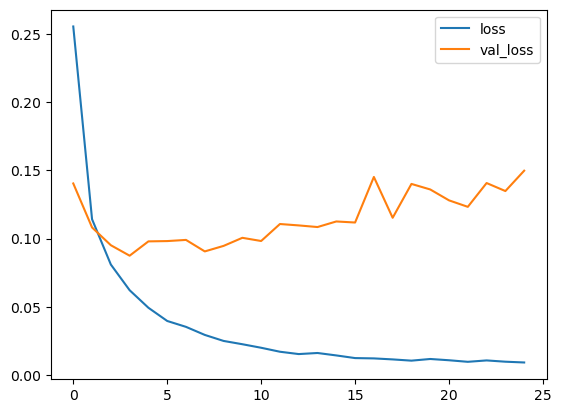

In [16]:
result[["loss","val_loss"]].plot()

<Axes: >

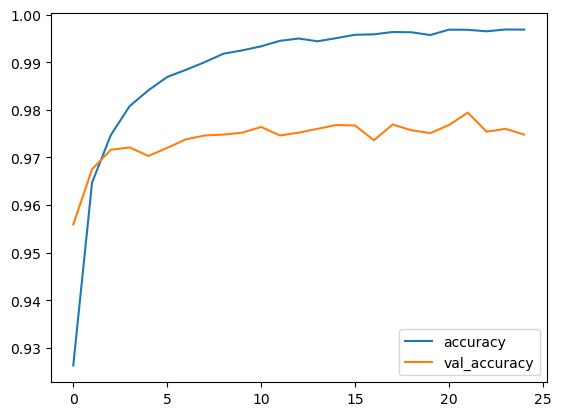

In [17]:
result[["accuracy","val_accuracy"]].plot()

In [18]:
y_pred=model.predict(X_test)

313/313 [==============================] - 1s 1ms/step


In [19]:
y_pred

array([[3.2750453e-17, 6.1966950e-16, 5.3243152e-13, ..., 1.0000000e+00,
        2.2948258e-17, 1.2879112e-14],
       [6.1564923e-18, 3.0365894e-11, 1.0000000e+00, ..., 1.1601016e-12,
        4.2746428e-17, 2.8971081e-30],
       [3.6099787e-17, 1.0000000e+00, 1.9154829e-10, ..., 1.1656247e-08,
        5.6760541e-10, 1.2239024e-17],
       ...,
       [2.2201045e-22, 4.8341704e-24, 8.1072616e-26, ..., 5.5679593e-13,
        3.1481074e-14, 2.8867262e-12],
       [1.0195324e-23, 1.9863699e-32, 2.6886463e-35, ..., 1.3652150e-26,
        5.0454653e-12, 4.8252006e-23],
       [1.3561387e-23, 6.6944647e-27, 6.8781174e-22, ..., 1.6618535e-32,
        3.5426895e-20, 2.9388012e-25]], dtype=float32)

In [87]:
y_pred.shape

(10000, 10)

In [88]:
y_pred.ndim

2

In [20]:
y_pred[0]

array([3.2750453e-17, 6.1966950e-16, 5.3243152e-13, 3.3138295e-12,
       2.6752528e-21, 7.1990998e-17, 1.9340590e-25, 1.0000000e+00,
       2.2948258e-17, 1.2879112e-14], dtype=float32)

In [22]:
y_test[0]

7

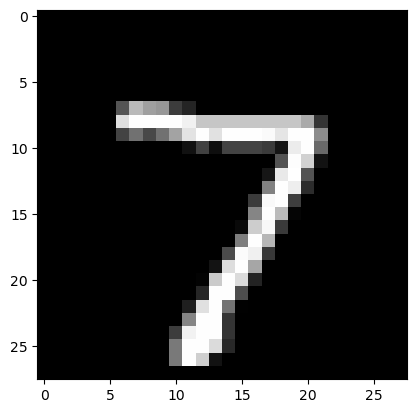

In [91]:
plt.imshow(X_test[0],cmap='gray')

In [23]:
np.argmax(y_pred[0])

7

In [93]:
y_test[:10]

array([7, 2, 1, 0, 4, 1, 4, 9, 5, 9], dtype=uint8)

In [94]:
y_pred_10=y_pred[0:10]

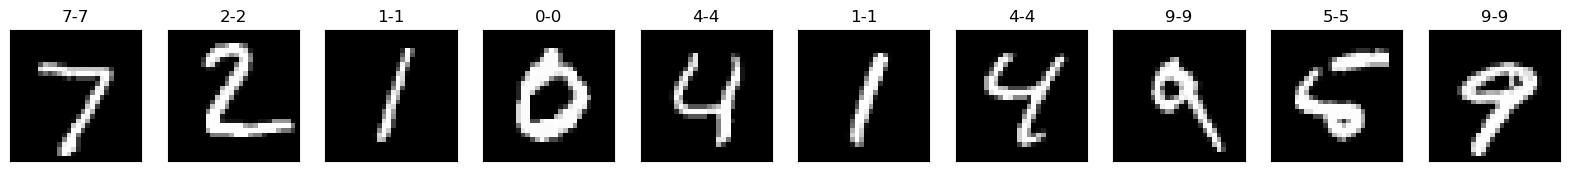

In [95]:
# Display some images
fig, axes = plt.subplots(ncols=10, sharex=False, 
    sharey=True, figsize=(20, 10))
for i in range(10):
    axes[i].set_title(str(y_test[i])+"-"+str(np.argmax(y_pred_10[i])))
    axes[i].imshow(X_test[i], cmap='gray')
    axes[i].get_xaxis().set_visible(False)
    axes[i].get_yaxis().set_visible(False)
plt.show()

In [96]:
final_y_predicted=np.argmax(y_pred,axis=1)
final_y_predicted

array([7, 2, 1, ..., 4, 5, 6], dtype=int64)

In [97]:
cm = tf.math.confusion_matrix(labels=y_test,predictions=final_y_predicted)
cm

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 973,    0,    0,    0,    1,    1,    1,    2,    1,    1],
       [   0, 1125,    3,    0,    0,    0,    3,    0,    4,    0],
       [   4,    3, 1004,    4,    1,    0,    5,    6,    4,    1],
       [   0,    0,    3,  987,    0,    6,    0,    5,    4,    5],
       [   2,    1,    3,    0,  957,    2,    3,    1,    2,   11],
       [   2,    0,    0,    7,    0,  872,    6,    1,    3,    1],
       [   6,    2,    0,    1,    4,    7,  935,    0,    3,    0],
       [   1,    3,    7,    6,    1,    0,    0, 1002,    0,    8],
       [   3,    0,    1,    7,    4,    5,    3,    3,  942,    6],
       [   2,    2,    1,    4,    9,    4,    0,    4,    1,  982]])>

Text(154.75, 0.5, 'Actual  digit')

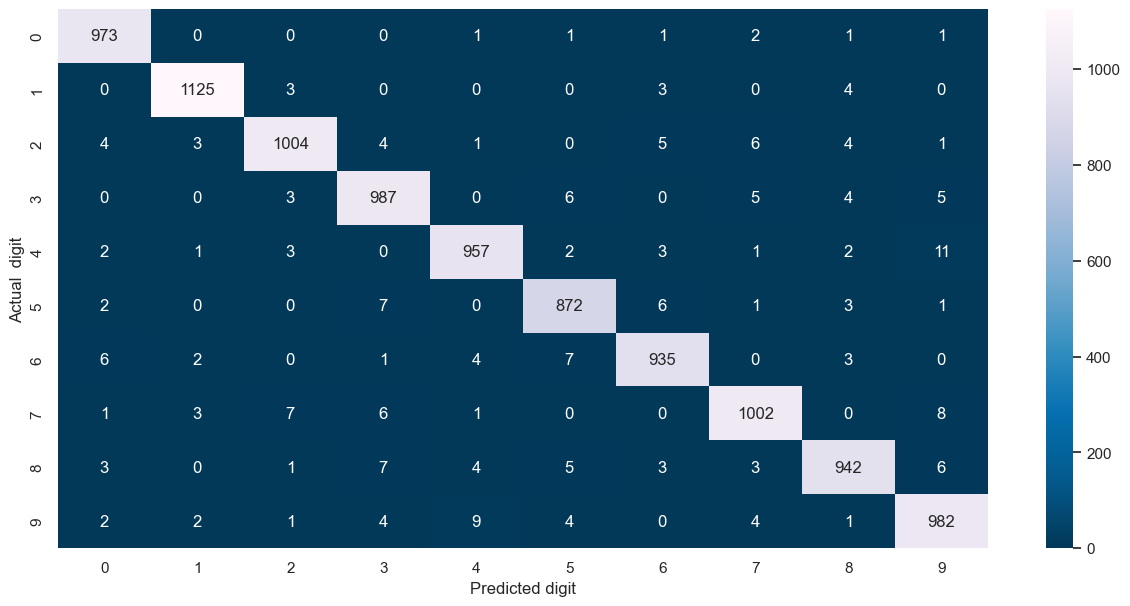

In [98]:
import seaborn as sns
sns.set(rc={'figure.figsize':(15,7)})
sns.heatmap(cm,annot=True,cmap='PuBu_r',fmt='g')
plt.xlabel("Predicted digit")
plt.ylabel("Actual  digit") 